In [1]:
from pathlib import Path
import sys
repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(repo_root / "src"))

%load_ext autoreload
%autoreload 2
import soccer_pattern_recognition as sc

import os
import time
import tqdm
import numpy as np
import pandas as pd

from sklearn.neighbors import LocalOutlierFactor
import matplotlib.pyplot as plt
import socceraction.spadl as spadl

In [2]:
datafolder = "../data"
fifa2018h5 = os.path.join(datafolder, "spadl-fifa2018.h5")
games = pd.read_hdf(fifa2018h5, key="games")
with pd.HDFStore(fifa2018h5) as store:
    actions = []  #list of DataFrames
    for game in tqdm.tqdm(games.itertuples()):
        game_action = store[f"actions/game_{game.game_id}"]
        game_action = spadl.play_left_to_right(game_action, game.home_team_id)
        game_action["is_home"] = game_action["team_id"] == game.home_team_id
        actions.append(game_action)
    actions = pd.concat(actions)
    actions.drop("original_event_id", axis=1, inplace=True)
    actions = pd.merge(actions, spadl.config.actiontypes_df(), how="left")

64it [00:00, 182.83it/s]


In [3]:
def consolidate(actions):
    #actions.fillna(0, inplace=True)

    #Consolidate corner_short and corner_crossed
    corner_idx = actions.type_name.str.contains("corner")
    actions["type_name"] = actions["type_name"].mask(corner_idx, "corner")

    #Consolidate freekick_short, freekick_crossed, and shot_freekick
    freekick_idx = actions.type_name.str.contains("freekick")
    actions["type_name"] = actions["type_name"].mask(freekick_idx, "freekick")

    #Consolidate keeper_claim, keeper_punch, keeper_save, keeper_pick_up
    keeper_idx = actions.type_name.str.contains("keeper")
    actions["type_name"] = actions["type_name"].mask(keeper_idx, "keeper_action")

    actions["start_x"] = actions["start_x"].mask(actions.type_name == "shot_penalty", 94.5)
    actions["start_y"] = actions["start_y"].mask(actions.type_name == "shot_penalty", 34)

    return actions


actions = consolidate(actions)

def add_noise(actions):
    # Start locations
    start_list = ["cross", "shot", "dribble", "pass", "keeper_action", "clearance", "goalkick"]
    mask = actions["type_name"].isin(start_list)
    noise = np.random.normal(0, 0.5, size=actions.loc[mask, ["start_x", "start_y"]].shape)
    actions.loc[mask, ["start_x", "start_y"]] += noise

    # End locations
    end_list = ["cross", "shot", "dribble", "pass", "keeper_action", "throw_in", "corner", "freekick", "shot_penalty"]
    mask = actions["type_name"].isin(end_list)
    noise = np.random.normal(0, 0.5, size=actions.loc[mask, ["end_x", "end_y"]].shape)
    actions.loc[mask, ["end_x", "end_y"]] += noise

    return actions

actions = add_noise(actions)

def remove_outliers(actions, verbose=False):
    X = actions[["start_x","start_y","end_x","end_y"]].to_numpy(dtype=float)
    inliers = LocalOutlierFactor(contamination="auto").fit_predict(X)
    if verbose:
        print(f"Remove {(inliers==-1).sum()} out of {X.shape[0]} datapoints.")
    return actions[inliers==1]

actions = remove_outliers(actions,True)

Remove 538 out of 128484 datapoints.


In [4]:
actions[["type_id", "type_name"]].drop_duplicates().sort_values("type_id")

,type_id,type_name
0,0,pass
80,1,cross
149,2,throw_in
99,3,freekick
154,4,freekick
140,5,corner
3908,6,corner
128,7,take_on
98,8,foul
129,9,tackle


In [5]:
actions["angle"] = np.arctan2(actions.end_y - actions.start_y, actions.end_x - actions.start_x)
actions["cos_angle"] = np.cos(actions["angle"])
actions["sin_angle"] = np.sin(actions["angle"])

ACTION_MAP = {'clearance': 0,
              'corner': 1,
              'cross': 2,
              'dribble': 3,
              'freekick': 4,
              'goalkick': 5,
              'keeper_action': 6,
              'pass': 7,
              'shot': 8,
              'throw_in': 9}

actions["action_type_id"] = actions["type_name"].map(ACTION_MAP)

In [6]:
actions.groupby("type_name").size()

type_name
bad_touch         1547
clearance         2046
corner             532
cross             1286
dribble          52522
foul              1876
freekick          1264
goalkick           676
interception      1681
keeper_action      583
pass             56244
shot              1525
shot_penalty        68
tackle            1830
take_on           2109
throw_in          2157
dtype: int64

In [7]:


action_set = set(ACTION_MAP.keys())

mask = (actions['game_id'] == 7585) & (actions['period_id']==1 & (actions['type_name'].isin(action_set)))

print(actions[mask]["type_name"].unique())
print(actions[mask].size)

['pass' 'dribble' 'cross' 'clearance' 'freekick' 'keeper_action' 'corner'
 'throw_in' 'shot' 'goalkick']
17043


In [8]:
data = actions[mask][["action_type_id","start_x", "start_y","cos_angle", "sin_angle"]].to_numpy()

In [9]:
emission_hyperparams = {'clearance': [4, "k-means",2,"k-means"],
              'corner': [2, "k-means",2,"k-means"],
              'cross': [4, "k-means",2,"k-means"],
              'dribble': [5, "k-means",2,"k-means"],
              'freekick': [3, "k-means",2,"k-means"],
              'goalkick': [2, "k-means",2,"k-means"],
              'keeper_action': [3, "k-means",2,"k-means"],
              'pass': [5, "k-means",2,"k-means"],
              'shot': [3, "k-means",2,"k-means"],
              'throw_in': [6, "k-means",2,"k-means"]}

model = sc.TwoLayerHMM(emission_hyperparams,2)

In [10]:
model.fit(data)

/Users/jgv/PycharmProjects/soccer-pattern-recognition/src/soccer_pattern_recognition/hierarchical/two_layer.py:103: RuntimeWarning: divide by zero encountered in log
  return logsumexp(np.log(loc_pdf) + dir_log_pdf, axis=1)  # (N,)


,emission_hyperparams,"{'clearance': [4, 'k-means', ...], 'corner': [2, 'k-means', ...], 'cross': [4, 'k-means', ...], 'dribble': [5, 'k-means', ...], ...}"
,n_components,2
,startprob_prior,1.0
,transmat_prior,1.0
,algorithm,'viterbi'
,random_state,None
,n_iter,10
,tol,0.01
,verbose,False
,params,'stam'
,init_params,'stam'


In [11]:
for action in ACTION_MAP.keys():
    for state in range(2):
        print(f"State: {state}, {action}")
        print(model.emission.action_mom_[state][action].layer1_mixture)
        print(model.emission.action_mom_[state][action].layer2_mixtures)

State: 0, clearance
MixtureModel(n_components=4)
  ├─ (0) w=0.213  MultivariateGaussian(d=2, mean=[ 6.442 29.499], cov=[[ 0. -0.], [-0.  0.]])
  ├─ (1) w=0.103  MultivariateGaussian(d=2, mean=[ 9.151 35.452], cov=[[10.001 -1.354], [-1.354  6.851]])
  ├─ (2) w=0.477  MultivariateGaussian(d=2, mean=[ 9.795 39.088], cov=[[7.844 4.873], [ 4.873 10.141]])
  └─ (3) w=0.207  MultivariateGaussian(d=2, mean=[20.158 33.52 ], cov=[[0. 0.], [0. 0.]])
[MixtureModel(n_components=2)
  ├─ (0) w=0.000  VonMises(loc=-98.8 deg, kappa=50.000)
  └─ (1) w=1.000  VonMises(loc=-13.4 deg, kappa=50.000), MixtureModel(n_components=2)
  ├─ (0) w=0.047  VonMises(loc=-35.4 deg, kappa=50.000)
  └─ (1) w=0.953  VonMises(loc=-0.3 deg, kappa=50.000), MixtureModel(n_components=2)
  ├─ (0) w=0.000  VonMises(loc=-66.4 deg, kappa=3.303)
  └─ (1) w=1.000  VonMises(loc=0.5 deg, kappa=50.000), MixtureModel(n_components=2)
  ├─ (0) w=0.941  VonMises(loc=-35.5 deg, kappa=50.000)
  └─ (1) w=0.059  VonMises(loc=-35.5 deg, kappa=5

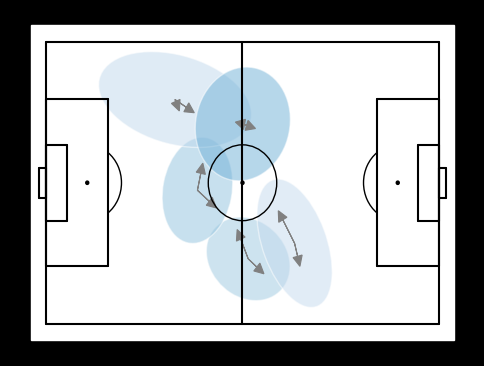

In [12]:
model.emission.action_mom_[0]["pass"].plot()

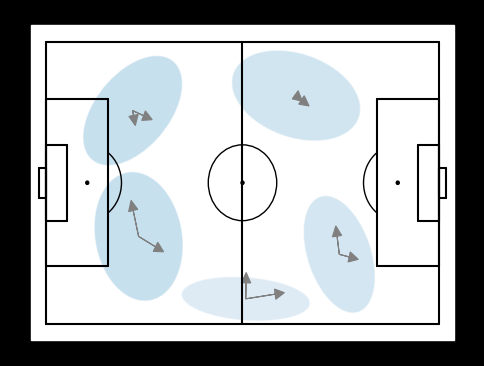

In [13]:
model.emission.action_mom_[1]["pass"].plot()